# Notebook 2 — Grids, masks, and harmonised hazard–exposure–vulnerability

This notebook takes the raw climate, population, and vulnerability inputs and turns them into **city-consistent grids and masks** on the UrbClim T2M reference grid, making them ready for impact calculations.

Concretely, it:

- **Initialises the city and climate scenario**
  - Repeats the generic project bootstrap used in NB 1 (city `slug`, paths `BASE/OUT/INT`, config).
  - Selects the **T2M climate scenario** (`T2M_SCEN`, here `"SP"`) and checks that required inputs (GVI, UrbClim WBGT, CAPZONE, hazard rasters, WorldPop, FUA) are present.

- **Builds future daily T2M fields on the UrbClim grid**
  - Loads **historical UrbClim daily mean 2 m temperature** (2008–2017) and constructs a “typical day” baseline: daily climatology by month (in K).
  - Reads **monthly temperature deltas** (°C) from a city-specific table for the chosen scenario and years (2030, 2040, 2050).
  - For each year, adds the monthly deltas to the baseline to generate a full **future daily T2M series** on the UrbClim grid, then:
    - Masks to the city’s FUA,
    - Converts to **°C**, and
    - Saves as NetCDF: `T2M_daily_mean_{year}_FUA_degC.nc`.
  - Prints city-mean monthly temperatures (baseline vs deltas vs future) and annual-mean T2M stats over FUA pixels.

- **Defines the common reference grid and city mask**
  - Uses the 2030 T2M NetCDF as the **reference hazard grid** (EPSG:3035, UrbClim LAEA Europe).
  - Extracts and stores the grid geometry: `transform`, `crs`, `shape`, and a 2D template array.
  - Builds a **city analysis mask** (`CITY_MASK`) marking pixels inside the FUA with non-zero population, to be reused across layers.

- **Aggregates WorldPop population by age group and reprojects to the T2M grid**
  - Loads 100 m **WorldPop 2030** rasters for Italy by 5-year age bands and masks them to the FUA.
  - Aggregates detailed bands into three groups: **`<15`**, **`15–64`**, **`65+`**, and computes FUA totals on the native grid.
  - Reprojects these age-group rasters to the **T2M reference grid** using `Resampling.sum`, obtaining:
    - Total population per T2M cell (`pop_on_ref`),
    - Age-specific population per cell (`age_on_ref`).
  - Checks that age-band sums match the total population on the ref grid and plots population on the T2M grid for visual inspection.

- **Projects future population by age group using Wittgenstein Centre data**
  - Reads **Wittgenstein Centre national projections** (`wicdf.csv`) for Italy (data dowloaded from the Wittgenstein Centre website) and maps detailed 5-year ages to the same three age groups.
  - Computes, for each **scenario × year (2030, 2040, 2050)**, national totals and **growth factors relative to 2030** for `<15`, `15–64`, and `65+`.
  - Applies these growth factors to the 2030 WorldPop-derived grids to create **future age-specific and total population grids** on the T2M reference:
    - Supports multiple SSP-style scenarios (e.g. `SSP1`, `SSP2`, `SSP3`, `SSP4`, `SSP5`, `SSP2DM`, `SSP2ZM`).
  - Summarises total population on the ref grid by scenario and year and writes a detailed **exposure manifest** linking scenarios/years to the saved `.npz` arrays.

- **Builds the vulnerability layer on the same grid**
  - Calls `build_vulnerability_layer(...)` to construct a **composite Social Vulnerability Index (SVI)** and its components on the T2M grid:
    - **Thermal vulnerability** from building age (GHS-AGE),
    - **Foreign-born share** from census data,
    - **Unemployment proxy** from working-age and employed census counts.
  - Saves the vulnerability outputs (component arrays and SVI) and produces quick maps of:
    - SVI,
    - Thermal vulnerability,
    - Foreign-born share,
    - Unemployment proxy.
  - Computes Pearson and Spearman correlations between components and SVI, showing that **foreign-born share and thermal vulnerability** are most strongly aligned with SVI, with unemployment still contributing but slightly less strongly.

- **Saves all common assets for downstream notebooks**
  - Writes:
    - `ref_meta.json`, `template_ref.tif` (reference grid definition),
    - `city_mask.npz` and `city_mask.tif`,
    - `hazard_manifest.json` (T2M hazard files and metadata),
    - Baseline exposure grids (`age_on_ref_rome.npz`, `pop_on_ref_rome.npz`),
    - Scenario/year exposure grids and `exposure_manifest.json`,
    - Convenience GeoTIFFs for 2030 population and age groups on the ref grid.
  - Stores the FUA boundary as `{slug}_fua.gpkg` for reuse.

In summary, Notebook 2 **harmonises hazard, exposure, and vulnerability onto a single, city-consistent grid** and produces all the masked rasters, manifests, and masks that later notebooks will use for heat-risk and adaptation analysis.

In [44]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [45]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()
# Rome by default 

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [46]:
T2M_SCEN = "SP" # choosing scenario we want for the UrbClim deltas 

In [47]:
cfg  = C.get("cfg")     # dict loaded from YAML

In [48]:
# climate scenario selection for UrbClim deltas 
clim_cfg = cfg.get("climate", {})

T2M_SCEN = globals().get(
    "T2M_SCEN",
    os.environ.get(
        "T2M_SCEN",
        clim_cfg.get("t2m_clim_scen_default", "CurPol") # Curpol by default
    )
)

options = clim_cfg.get("t2m_clim_scen_options", [])
if options and T2M_SCEN not in options:
    raise ValueError(f"T2M_SCEN={T2M_SCEN!r} not in allowed options: {options}")

print(f"→ Using climate deltas scenario: {T2M_SCEN}")

→ Using climate deltas scenario: SP


In [49]:
# City-agnostic required inputs
required = [
    P(cfg["files"]["gvi_csv"]),
    P("UrbClim/UrbClimWBGTmax/WBGT_year_daily_max_2014.nc"),
    P("CAPZONE/CAPZONE.shp"),
    P("hazard"),
    P("worldpop"),
    P("fua"), 
]
missing = [p for p in required if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "Some inputs are missing. Run Notebook 1 (Drive sync) first:\n" +
        "\n".join(str(p) for p in missing)
)

In [50]:
import geopandas as gpd

p_FUA = P("fua")
candidates = sorted(p_FUA.glob("*.geojson")) + sorted(p_FUA.glob("*.gpkg")) + sorted(p_FUA.glob("*.shp"))
candidates = [p for p in candidates if SLUG in p.stem.lower()] or candidates
assert candidates, f"No FUA file found in {p_FUA}"
fua_path = candidates[0]

fua = gpd.read_file(fua_path)
if fua.empty:
    raise ValueError("Loaded FUA is empty.")

## T2M Mean Daily Temperature 

> **T2M mean daily temperature:**
> - Loading historical daily T2M (kelvin) and build "typical day" baseline
> - Read monthly deltas (different scenarios possible) for each projected target year
> - Build future daily series from baseline + monthly deltas
> - Mask for city's FUA on UrbClim grid
> - Apply mask and convert to °C

In [51]:
# Future DAILY T2M for 2030/2040/2050 (UrbClim + monthly change °C), masked to FUA and saved in °C
import os
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr
import geopandas as gpd
from affine import Affine
import rasterio.features as rfeat
from rasterio.crs import CRS

# Baseline climatology (2008–2017) on UrbClim grid 
t2m_dir   = P("UrbClim/UrbClimT2Mmean")
t2m_files = sorted(t2m_dir.glob("T2M_year_daily_mean_*.nc"))
assert t2m_files, "No T2M_year_daily_mean_*.nc files found."
ds = xr.open_mfdataset(t2m_files, combine="by_coords", decode_times=True)
vname = next((v for v in ("T2M","t2m","tas","temperature") if v in ds.data_vars), list(ds.data_vars)[0])
daK = ds[vname]  # (time,y,x), K

md_clim = daK.groupby("time.month").map(lambda grp: grp.groupby("time.day").mean("time"))
md_clim = md_clim.reindex(day=np.arange(1, 32)).ffill("day")

# grid axes (safe to use after ds.close), I needed to do this because if file not closed, can be a problem later to use it
x = md_clim["x"].values
y = md_clim["y"].values
ds.close()

# Monthly deltas from single long table (city, year, clim_scen, var, month, delta) 
import pandas as pd

deltas_table_path = P(cfg["files"]["t2m_deltas_table"])
df_deltas = pd.read_csv(deltas_table_path)

# years we want to build, if not in climate.years, fall back to ac.years
wanted_years = clim_cfg.get("years", cfg.get("ac", {}).get("years", [2030, 2040, 2050]))
wanted_years = list(wanted_years)

# city matching: use aliases if present, else city_name/slug
# (there are both in my YAML)
city_aliases = cfg.get("cooling_city_aliases") or [
    cfg.get("city_name", CITY),
    CITY,
    SLUG,
    SLUG.capitalize(),
]
city_aliases_low = [c.lower() for c in city_aliases]

t2m_var = clim_cfg.get("t2m_var", "tas")

def read_monthly_delta_C(year: int) -> np.ndarray:
    """Return 12-element array (Jan..Dec) of deltas in °C for given year + scenario."""
    df = df_deltas.copy()
    df["city_low"] = df["city"].str.lower()

    sub = df[
        df["city_low"].isin(city_aliases_low)
        & (df["year"] == year)
        & (df["clim_scen"] == T2M_SCEN)
        & (df["var"] == t2m_var)
    ]

    if sub.empty:
        raise ValueError(
            f"No climate deltas found in {deltas_table_path} for "
            f"city={city_aliases} year={year} scen={T2M_SCEN} var={t2m_var}"
        )

    # expect one row per month, month in 1..12 (integer)
    sub = sub.sort_values("month")
    if sub["month"].nunique() != 12:
        raise ValueError(
            f"Expected 12 months of deltas for year={year}, scen={T2M_SCEN}, "
            f"got {sub['month'].nunique()}"
        )

    deltas = (
        sub.set_index("month")
           .loc[range(1, 13), "delta"]
           .astype(float)
           .to_numpy()
    )
    return deltas

for yr in wanted_years:
    # just to show what we’re using
    dmC = read_monthly_delta_C(yr)
    print(f"ΔT (scenario={T2M_SCEN}) for {yr}: {dmC}")

# building future daily from baseline + monthly deltas 
def build_future_daily(yr: int, md_baseK: xr.DataArray, month_deltaC: np.ndarray) -> xr.DataArray:
    times = pd.date_range(f"{yr}-01-01", f"{yr}-12-31", freq="D")
    months = []
    for m in range(1, 13):
        ndays = int((times.month == m).sum())
        base_md = md_baseK.sel(month=m).isel(day=slice(0, ndays))
        fut_md  = base_md + float(month_deltaC[m-1])  # add °C to K (same increment)
        months.append(fut_md)
    futK = xr.concat(months, dim="day").rename({"day":"time"}).assign_coords(time=times)
    futK.name = "T2M"
    return futK.assign_attrs(units="K")

# FUA mask on the same (x,y) grid, EPSG:3035 
p_FUA = P("fua")
fua_path = (sorted(p_FUA.glob("*.geojson")) + sorted(p_FUA.glob("*.gpkg")) + sorted(p_FUA.glob("*.shp")))[0]
fua = gpd.read_file(fua_path).to_crs(CRS.from_epsg(3035))

dx = float(abs(np.diff(x).mean()))
dy = float(abs(np.diff(y).mean()))
transform = Affine.translation(float(x.min()) - dx/2,
                               float(y.max()) + dy/2) * Affine.scale(dx, -dy)

fua_mask = rfeat.geometry_mask(
    [g for g in fua.geometry if g is not None],
    out_shape=(len(y), len(x)),
    transform=transform,
    invert=True
)
fua_mask_da = xr.DataArray(fua_mask, coords={"y": y, "x": x}, dims=("y", "x"))

# I saved like this because I had a problem saving before: sometimes the drive synch creates problems
def robust_save(da: xr.DataArray, out_nc: Path):
    out_nc = str(out_nc)
    if os.path.exists(out_nc):
        try:
            os.chmod(out_nc, 0o644)
            os.remove(out_nc)
        except Exception as e:
            raise RuntimeError(f"Close any app using {out_nc} and retry. ({e})")
    tmp = out_nc + ".tmp"
    try:
        da.to_dataset(name=da.name or "T2M").to_netcdf(tmp, mode="w", engine="netcdf4")
        os.replace(tmp, out_nc)
    except Exception:
        try:
            if os.path.exists(tmp): os.remove(tmp)
        except Exception:
            pass
        da.to_dataset(name=da.name or "T2M").to_netcdf(tmp, mode="w", engine="scipy")
        os.replace(tmp, out_nc)

# computing and saving per year (masked °C)
zeros = np.zeros(12)
for year in wanted_years:
    dmC = read_monthly_delta_C(year)   # now uses scenario + table

    futK = build_future_daily(year, md_clim, dmC)
    futC = (futK.where(fua_mask_da) - 273.15).astype("float32")
    futC.name = "T2M"
    futC = futC.assign_attrs(units="degC", source_units="K")

    baseK_samecal = build_future_daily(year, md_clim, zeros)
    baseC_samecal = (baseK_samecal.where(fua_mask_da) - 273.15)

    base_monthC = baseC_samecal.groupby("time.month").mean(("time","y","x")).values
    fut_monthC  = futC.groupby("time.month").mean(("time","y","x")).values

    print(f"\n{year} ({T2M_SCEN}) city-mean monthly (°C) — base(same cal) | delta | future")
    for m in range(12):
        print(f"{m+1:02d}: {base_monthC[m]:6.2f} | {dmC[m]:+6.2f} | {fut_monthC[m]:6.2f}")

    out_nc = OUTP(f"hazard/T2M_daily_mean_{year}_FUA_degC.nc")
    robust_save(futC, out_nc)
    print(f"Saved {out_nc}")

ΔT (scenario=SP) for 2030: [0.36094776 0.32480932 0.31429848 0.28366805 0.37106103 0.46064362
 0.42993839 0.43632563 0.47972896 0.31693226 0.32279217 0.24275546]
ΔT (scenario=SP) for 2040: [0.72247843 0.53338944 0.56647871 0.40334401 0.47684997 0.5641668
 0.69641104 0.6649091  0.66099701 0.66810218 0.52396862 0.4931247 ]
ΔT (scenario=SP) for 2050: [0.47092733 0.39515635 0.48587337 0.37852589 0.41884725 0.48117363
 0.5422291  0.5397656  0.66816237 0.5881844  0.44214805 0.41771007]

2030 (SP) city-mean monthly (°C) — base(same cal) | delta | future
01:   7.95 |  +0.36 |   8.31
02:   8.18 |  +0.32 |   8.51
03:  11.00 |  +0.31 |  11.31
04:  14.00 |  +0.28 |  14.28
05:  17.20 |  +0.37 |  17.57
06:  21.05 |  +0.46 |  21.51
07:  23.86 |  +0.43 |  24.29
08:  24.23 |  +0.44 |  24.67
09:  20.91 |  +0.48 |  21.39
10:  16.83 |  +0.32 |  17.15
11:  12.71 |  +0.32 |  13.03
12:   9.41 |  +0.24 |   9.66
Saved /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/hazard/T2M_daily_

In [52]:
# Ref grid = UrbClim T2M grid (EPSG:3035) (exactly as our WBGT grid before)
import xarray as xr
from affine import Affine
from rasterio.crs import CRS

# using any of T2M outputs we saved (2030/2040/2050 all share the grid)
t2m_ref_nc = OUTP("hazard/T2M_daily_mean_2030_FUA_degC.nc")
ds_ref = xr.open_dataset(t2m_ref_nc)
da_ref = ds_ref["T2M"].isel(time=0)      # (y,x) slice on the UrbClim grid

x = da_ref["x"].values
y = da_ref["y"].values
dx = float(abs(np.diff(x).mean()))
dy = float(abs(np.diff(y).mean()))

ref_transform = Affine.translation(float(x.min()) - dx/2,
                                   float(y.max()) + dy/2) * Affine.scale(dx, -dy)

ref_crs       = CRS.from_epsg(3035)      # UrbClim T2M is on LAEA Europe
ref_shape     = (da_ref.sizes["y"], da_ref.sizes["x"])

ref_meta = {
    "crs": ref_crs,
    "transform": ref_transform,
    "height": ref_shape[0],
    "width":  ref_shape[1],
    "dtype": "float32",
}

ref_data = da_ref.values   # contains NaNs outside FUA

**Age-grouped** WorldPop data

In [53]:
# Helper: read a raster, reproject FUA to its CRS, mask+crop to FUA, return array+metadata
import numpy as np
import rasterio as rio
from rasterio.mask import mask as rio_mask

def read_and_mask_to_fua(raster_path, fua_gdf):
    with rio.open(raster_path) as src:
        src_crs = src.crs
        fua_in_src = fua_gdf.to_crs(src_crs)
        geoms = [g for g in fua_in_src.geometry if g is not None]
        if not geoms:
            raise ValueError("FUA geometry is empty/invalid.")
        out, out_transform = rio_mask(
            src, geoms, crop=True, filled=True, nodata=np.nan
        )
        meta = src.meta.copy()
        meta.update(height=out.shape[1], width=out.shape[2], transform=out_transform)
        data = out[0].astype(float)
    return data, out_transform, src_crs, meta

In [54]:
# WorldPop age groups on native grid, then onto T2M ref grid 

from rasterio.warp import reproject
from rasterio.enums import Resampling
import numpy as np
import rasterio as rio
import geopandas as gpd

year    = 2030
release = "R2025A"
version = "v1"
gender  = "t"

AGE_GROUPS = {
    "<15":   ["00", "01", "05", "10"],
    "15-64": ["15","20","25","30","35","40","45","50","55","60"],
    "65+":   ["65","70","75","80","85","90"],
}
ALL_CODES = [c for L in AGE_GROUPS.values() for c in L]

def worldpop_age_path(code):
    patt = f"ita_{gender}_{code}_{year}_CN_100m_{release}_{version}.tif*"
    candidates = sorted((P("worldpop")).rglob(patt))  # search recursively
    if not candidates:
        raise FileNotFoundError(f"No WorldPop file matching: {patt} under {P('worldpop')}")
    return candidates[0]

def build_age_group_rasters(fua_gdf):
    agg = {"<15": None, "15-64": None, "65+": None}
    wp_meta = None
    for code in ALL_CODES:
        arr, _, _, meta = read_and_mask_to_fua(worldpop_age_path(code), fua_gdf)
        arr = np.nan_to_num(arr, nan=0.0).astype(np.float32)
        if wp_meta is None:
            wp_meta = meta
        for grp, codes in AGE_GROUPS.items():
            if code in codes:
                agg[grp] = arr if agg[grp] is None else (agg[grp] + arr)
                break
    for k, v in agg.items():
        if v is None:
            agg[k] = np.zeros_like(next(x for x in agg.values() if x is not None), dtype=np.float32)
    return agg, wp_meta

age_native, wp_meta = build_age_group_rasters(fua)

print("Native-grid totals within FUA (people):")
for k, v in age_native.items():
    print(f"  {k:>5}: {float(v.sum()):,.0f}")

def reproject_sum_to_ref(src_arr, src_meta, ref_meta, ref_like):
    out = np.zeros_like(ref_like, dtype=float)
    reproject(
        source=np.nan_to_num(src_arr, nan=0.0),
        destination=out,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"],
        dst_crs=ref_meta["crs"],
        resampling=Resampling.sum,
        src_nodata=0.0,
        dst_nodata=0.0,
    )
    return np.where(np.isfinite(ref_like), out, 0.0)

# total pop then age bands on ref grid
pop_native = sum(np.nan_to_num(v, nan=0.0) for v in age_native.values())
pop_on_ref = reproject_sum_to_ref(pop_native, wp_meta, ref_meta, ref_data)

age_on_ref = {
    grp: reproject_sum_to_ref(arr, wp_meta, ref_meta, ref_data)
    for grp, arr in age_native.items()
}

native_total = float(pop_native.sum())
ref_total    = float(pop_on_ref.sum())
print("\nPopulation totals (people):")
print(f"  WP-native sum over FUA  : {native_total:,.0f}")
print(f"  T2M-grid sum (reproj): {ref_total:,.0f}")

Native-grid totals within FUA (people):
    <15: 63,254
  15-64: 400,909
    65+: 228,226

Population totals (people):
  WP-native sum over FUA  : 692,389
  T2M-grid sum (reproj): 576,550


In [55]:
assert pop_on_ref.shape == (ref_meta["height"], ref_meta["width"]), "Pop grid != ref grid shape"
for k, a in age_on_ref.items():
    assert a.shape == pop_on_ref.shape, f"Age band {k} shape != ref grid"

In [56]:
# defining mask for later
CITY_MASK = np.isfinite(ref_data) & (pop_on_ref > 0) # main analysis mask         

# Consistency check: do age bands add up to pop_on_ref?
pop_from_ages = np.zeros_like(pop_on_ref, dtype=float)
for a in age_on_ref.values():
    pop_from_ages += np.nan_to_num(a)

abs_diff = float(np.abs(np.nansum(pop_from_ages) - np.nansum(pop_on_ref)))
rel_diff = abs_diff / max(np.nansum(pop_on_ref), 1.0)

print("\nSanity check — totals on T2M grid (people):")
for k, v in age_on_ref.items():
    print(f"  {k:>5}: {float(np.nansum(v)):.0f}")
print(f"  Sum(age bands): {float(np.nansum(pop_from_ages)):.0f}") # yes it does
print(f"  pop_on_ref    : {float(np.nansum(pop_on_ref)):.0f}")
print(f"  Abs diff      : {abs_diff:.3f}  ({100*rel_diff:.4f}%)")


Sanity check — totals on T2M grid (people):
    <15: 53034
  15-64: 334769
    65+: 188747
  Sum(age bands): 576550
  pop_on_ref    : 576550
  Abs diff      : 0.000  (0.0000%)


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Here, I implement an age-specific population scaling using Wittgenstein Center projections. I start with the high-resolution WorldPop 2030 data (100m) for all age groups. I use Wittgenstein Center projections to calculate growth rates between 2030 and 2040, and 2040 and 2050. The growth rates are age-specific and spatially distributed. I multiply the WoldPop 2030 data by these growth factors to get 2040 and 2050 populations. I do a scaling separately for each age group. 
</blockquote>

In [57]:
# FUTURE POPULATION BY AGE GROUP (2030, 2040, 2050) VIA WITTGENSTEIN

import re

wic_csv = P("worldpop/wicdf.csv") # csv that I've put in the drive, under "population"
print("WIC file:", wic_csv)

# Wittgenstein export uses ";" as separator
wic = pd.read_csv(wic_csv, sep=";")
print("Columns in WIC:", wic.columns.tolist())

# keeping only Italy (it is already actually, in what I've downloaded)
wic_ita = wic[wic["Area"] == "Italy"].copy()
print("Rows for Italy:", len(wic_ita))

# ensuring Year is integer
wic_ita["Year"] = pd.to_numeric(wic_ita["Year"], errors="coerce")
wic_ita = wic_ita.dropna(subset=["Year"])
wic_ita["Year"] = wic_ita["Year"].astype(int)

print("Unique years in Italy subset:", sorted(wic_ita["Year"].unique()))

# mapping fine age buckets to 3 big age buckets  
lt15   = ["0--4","5--9","10--14"]
a15_64 = ["15--19","20--24","25--29","30--34","35--39","40--44",
          "45--49","50--54","55--59","60--64"]
g65    = ["65--69","70--74","75--79","80--84","85--89",
          "90--94","95--99","100"]

AGE_MAP = {a: "<15"   for a in lt15}
AGE_MAP.update({a: "15-64" for a in a15_64})
AGE_MAP.update({a: "65+"   for a in g65})

wic_ita["big_age"] = wic_ita["Age"].map(AGE_MAP)
wic_ita = wic_ita.dropna(subset=["big_age"])

# pop is in thousands => converting to persons
wic_ita["pop"] = wic_ita["Population"] * 1_000.0

# aggregating to big age groups by Scenario × Year
totals = (
    wic_ita
    .groupby(["Scenario", "Year", "big_age"])["pop"]
    .sum()
    .sort_index()
)

print("\nNational totals (Italy, people) – first few:")
print(totals.head(12))

# pivot: rows = (Scenario, Year), columns = big_age
tot_df = totals.reset_index()  # Scenario, Year, big_age, pop

pivot = (
    tot_df
    .pivot_table(index=["Scenario", "Year"], columns="big_age", values="pop")
    .sort_index()
)

print("\nPivot table head (Scenario, Year → big_age columns):")
print(pivot.head())

# growth factors relative to 2030 by scenario 
if 2030 not in pivot.index.get_level_values("Year"):
    raise ValueError("Year 2030 not found in WIC data – cannot compute growth factors.")

base_2030 = pivot.xs(2030, level="Year")   # index = Scenario, columns = big_age

# dividing by 2030 within each Scenario
growth_rel = pivot.div(base_2030, level="Scenario")
print("\nGrowth factors (few rows):")
print(growth_rel.head(12))

def scen_code(raw: str) -> str:
    """
    Clean up WIC scenario labels into nice codes, e.g.
    '1,00 SSP' -> 'SSP1', 'SSP2ZM' -> 'SSP2ZM'
    """
    raw = str(raw).replace("\xa0", " ").strip()
    m = re.match(r"^(\d+),\d+\s*SSP$", raw)
    if m:
        return f"SSP{m.group(1)}"
    return raw.replace(" ", "_")

scenario_labels = sorted(wic_ita["Scenario"].unique())
print("\nScenarios in WIC and sanitized codes:")
for s in scenario_labels:
    print(f"  {s!r} -> {scen_code(s)}")

AGE_KEYS = ["<15", "15-64", "65+"]

# building future age-specific grids by scaling the 2030 WorldPop grids 
# age_on_ref:  dict {"<15": array, "15-64": array, "65+": array}  (already built)
# pop_on_ref:  array with total pop (sum of age groups)

future_age_on_ref = {}   # future_age_on_ref[scen][year][age_group] -> 2D array
future_pop_on_ref = {}   # future_pop_on_ref[scen][year] -> 2D array

YEARS_TARGET = (2030, 2040, 2050)

for scen_raw in scenario_labels:
    s_code = scen_code(scen_raw)
    future_age_on_ref[s_code] = {}
    future_pop_on_ref[s_code] = {}

    for year in YEARS_TARGET:
        if year == 2030:
            # 2030 = baseline WorldPop; reuse the grids
            future_age_on_ref[s_code][year] = {
                k: v.astype("float32").copy()
                for k, v in age_on_ref.items()
            }
            fut_pop = sum(future_age_on_ref[s_code][year].values())
            future_pop_on_ref[s_code][year] = fut_pop.astype("float32")
            continue

        # Check that growth factors exist for this (Scenario, Year)
        if (scen_raw, year) not in growth_rel.index:
            raise KeyError(
                f"No WIC growth factors for Scenario={scen_raw!r}, Year={year}. "
                "Check wicdf.csv content."
            )

        grids = {}
        for grp in AGE_KEYS:
            if grp not in growth_rel.columns:
                raise KeyError(
                    f"Age group {grp!r} missing from growth_rel columns: {growth_rel.columns.tolist()}"
                )
            g = float(growth_rel.loc[(scen_raw, year), grp])  # scalar factor
            grids[grp] = (age_on_ref[grp] * g).astype("float32")

        future_age_on_ref[s_code][year] = grids
        fut_pop = sum(grids.values())
        future_pop_on_ref[s_code][year] = fut_pop.astype("float32")

print("\nCheck: total population on T2M grid by scenario/year (people):")
for s_raw in scenario_labels:
    s_code = scen_code(s_raw)
    line = [s_code]
    for year in YEARS_TARGET:
        tot = float(np.nansum(future_pop_on_ref[s_code][year]))
        line.append(f"{year}: {tot:,.0f}")
    print("  " + "  |  ".join(line))

WIC file: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/worldpop/wicdf.csv
Columns in WIC: ['Scenario', 'Area', 'Year', 'Age', 'Population']
Rows for Italy: 441
Unique years in Italy subset: [2030, 2040, 2050]

National totals (Italy, people) – first few:
Scenario  Year  big_age
1,00 SSP  2030  15-64      35650900.0
                65+        16547500.0
                <15         6201000.0
          2040  15-64      31319500.0
                65+        20385300.0
                <15         5758700.0
          2050  15-64      28449200.0
                65+        22449200.0
                <15         5851100.0
2,00 SSP  2030  15-64      35599300.0
                65+        16245700.0
                <15         6353600.0
Name: pop, dtype: float64

Pivot table head (Scenario, Year → big_age columns):
big_age             15-64         65+        <15
Scenario Year                                   
1,00 SSP 2030  35650900.0  16547500.0  6201000.0
         2

In [58]:
import json

expo_meta = {
    # original key 
    "worldpop_year": 2030,
    # richer metadata
    "worldpop_base_year": 2030,
    "wic_years": list(YEARS_TARGET),   # [2030, 2040, 2050]
    "wic_scenarios": {scen_code(s): str(s) for s in scenario_labels},
    "age_groups": AGE_KEYS,            # ["<15", "15-64", "65+"]
}

with open(INT / "exposure_meta.json", "w") as f:
    json.dump(expo_meta, f, indent=2)

print("Updated exposure_meta.json:", INT / "exposure_meta.json")

Updated exposure_meta.json: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/exposure_meta.json


In [59]:
# some stat on T2M hazard 
import numpy as np, xarray as xr

years = (2030, 2040, 2050)

def load_t2m(year):
    ds = xr.open_dataset(OUTP(f"hazard/T2M_daily_mean_{year}_FUA_degC.nc"))
    return ds["T2M"]  # (time,y,x) in °C, NaN outside FUA

print("T2M annual-mean (°C) — city distribution over FUA pixels")
for y in years:
    da = load_t2m(y)
    annual_mean = da.mean("time")                       
    v = annual_mean.values[np.isfinite(annual_mean)]    
    print(f"{y}: min={np.min(v):.2f}, median={np.median(v):.2f}, p95={np.percentile(v,95):.2f}, max={np.max(v):.2f}")

T2M annual-mean (°C) — city distribution over FUA pixels
2030: min=9.66, median=16.66, p95=16.82, max=17.21
2040: min=9.87, median=16.87, p95=17.03, max=17.42
2050: min=9.79, median=16.79, p95=16.94, max=17.34


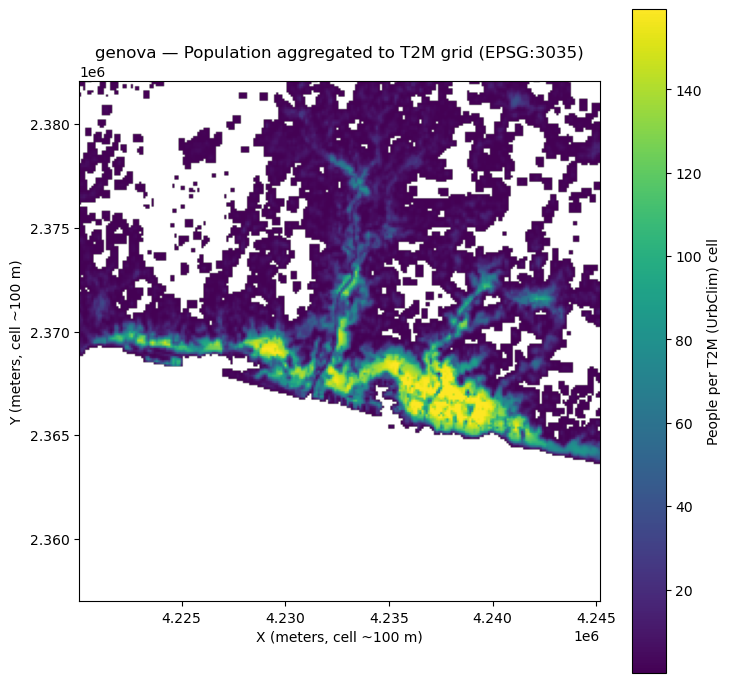

In [60]:
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds
import numpy as np

plot_arr = np.where(CITY_MASK, pop_on_ref, np.nan)
h, w = plot_arr.shape
left, bottom, right, top = array_bounds(h, w, ref_meta["transform"])

vmax   = np.nanpercentile(plot_arr, 99)
origin = 'upper' if ref_meta["transform"].e < 0 else 'lower'  

plt.figure(figsize=(7.5, 7))
im = plt.imshow(
    plot_arr,
    extent=(left, right, bottom, top),
    origin=origin,
    vmax=vmax,
)
cb = plt.colorbar(im); cb.set_label("People per T2M (UrbClim) cell")

ax = plt.gca()
ax.set_xlim(left, right)
ax.set_ylim(bottom, top)          
if ax.yaxis_inverted():          
    ax.invert_yaxis()            

dx = ref_meta["transform"].a
dy = abs(ref_meta["transform"].e)
plt.title(f"{CITY} — Population aggregated to T2M grid (EPSG:3035)")
plt.xlabel(f"X (meters, cell ~{dx:.0f} m)")
plt.ylabel(f"Y (meters, cell ~{dy:.0f} m)")
ax.set_aspect('equal', 'box')
plt.tight_layout(); plt.show()

## Vulnerability layer

VULNERABILITY LAYER — GENOVA

[1] Processing vulnerability components...
  Processing GHS-AGE: GHS_AGE_1975052020_GLOBE_R2025A_54009_100_V1_0.tif
    Built-up pixels: 16,392
    Range: 0.00 – 1.00
  Processing Census foreign-born share
    Valid pixels: 25,369
    Share range: 0.0% – 37.5%
  Processing Census unemployment (using actual working-age pop)
    Valid pixels: 25,218
    Non-emp range: 0.0% – 100.0%

[2] Computing Social Vulnerability Index...
    Valid pixels: 25,800
    SVI range: 0.000 – 1.000
    SVI mean:  0.554 ± 0.230

[3] Saved outputs:
    → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/vulnerability_genova.npz
    → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/vulnerability_svi_genova.tif


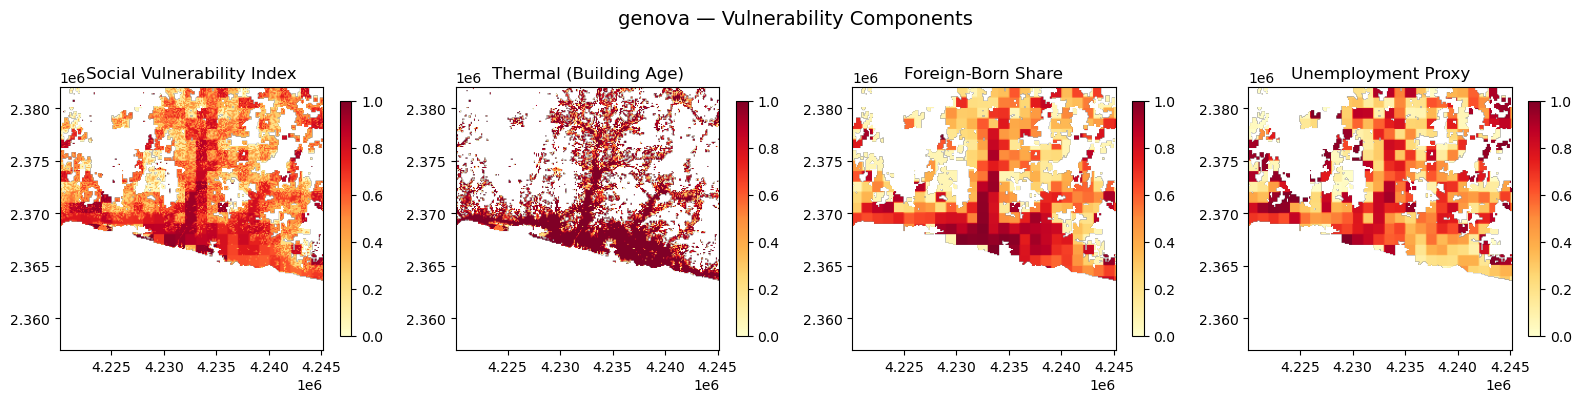

In [61]:
# this is built from : cityheat/vulnerability_layer.py
# here we just run what is in the python notebook (functions...)
from cityheat.vulnerability_layer import build_vulnerability_layer
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

vuln_cfg = cfg.get("vulnerability", {})
if vuln_cfg.get("enabled", True):
    vuln = build_vulnerability_layer(
        cfg, 
        ref_meta,
        CITY_MASK,
        fua,
        int_dir=INT,
        base_path=BASE,   
        verbose=True
    )
    
    # visualisation
    h, w = vuln["svi"].shape
    left, bottom, right, top = array_bounds(h, w, ref_meta["transform"])
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    titles = ["Social Vulnerability Index", "Thermal (Building Age)", 
              "Foreign-Born Share", "Unemployment Proxy"]
    arrays = [vuln["svi"], vuln["thermal"], vuln["foreign"], vuln["unemp"]]
    
    for ax, title, arr in zip(axes, titles, arrays):
        plot_arr = np.where(CITY_MASK, arr, np.nan)
        im = ax.imshow(plot_arr, extent=(left, right, bottom, top), 
                      origin='upper', cmap='YlOrRd', vmin=0, vmax=1)
        ax.set_title(title)
        ax.set_aspect('equal')
        plt.colorbar(im, ax=ax, shrink=0.7)
    
    plt.suptitle(f"{CITY} — Vulnerability Components", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Vulnerability layer disabled in config")

**Interpretation:** 
valid pixels: 25,800: raster grid, each pixel 100x100m, 25,800 grid cells within Genovza FUA with valid vulnerability data. Vulnerability of mean: 0.554 (more towards more vulnerable but less than in Rome) with a st deviation of 0.230. 

Should look at correlations of the vulnerability components!

In [62]:
import numpy as np
import pandas as pd

components = {
    "thermal": vuln["thermal"],
    "foreign": vuln["foreign"],
    "unemp":   vuln["unemp"],
    "svi":     vuln["svi"],
}

# pixels where everything is defined and inside the city
mask = CITY_MASK.copy()
for arr in components.values():
    mask &= np.isfinite(arr)

flat = {name: arr[mask].ravel() for name, arr in components.items()}
df = pd.DataFrame(flat)

# Pearson (linear) correlations
corr_pearson  = df.corr(method="pearson")
# Spearman 
corr_spearman = df.corr(method="spearman")

print("Pearson correlations:\n", corr_pearson)
print("\nSpearman correlations:\n", corr_spearman)

Pearson correlations:
           thermal   foreign     unemp       svi
thermal  1.000000  0.197989  0.035647  0.657387
foreign  0.197989  1.000000  0.323858  0.734823
unemp    0.035647  0.323858  1.000000  0.632075
svi      0.657387  0.734823  0.632075  1.000000

Spearman correlations:
           thermal   foreign     unemp       svi
thermal  1.000000  0.227491  0.031577  0.605944
foreign  0.227491  1.000000  0.337865  0.755721
unemp    0.031577  0.337865  1.000000  0.631299
svi      0.605944  0.755721  0.631299  1.000000


In [63]:
import numpy as np
import pandas as pd

from cityheat.vulnerability_layer import (
    get_vuln_config,
    resolve_path,
    reproject_to_ref,
)

vuln_cfg = get_vuln_config(cfg)
census_nodata = vuln_cfg.get("census_nodata", -9999)

# foreign-born share (raw) 

pop_path = resolve_path(cfg, vuln_cfg["files"]["census_pop"], base_path=BASE)
oth_path = resolve_path(cfg, vuln_cfg["files"]["census_oth"], base_path=BASE)

pop_total = reproject_to_ref(
    pop_path, ref_meta,
    resampling="sum",
    src_nodata=census_nodata
)
pop_oth   = reproject_to_ref(
    oth_path, ref_meta,
    resampling="sum",
    src_nodata=census_nodata
)

valid_foreign = (
    (pop_total > 0) &
    np.isfinite(pop_total) &
    np.isfinite(pop_oth) &
    CITY_MASK
)

foreign_share_raw = np.full_like(pop_total, np.nan, dtype=np.float32)
foreign_share_raw[valid_foreign] = np.clip(
    pop_oth[valid_foreign] / pop_total[valid_foreign],
    0, 1
)

# unemployment proxy (raw non-employment rate) 

wa_path  = resolve_path(cfg, vuln_cfg["files"]["census_working_age"], base_path=BASE)
emp_path = resolve_path(cfg, vuln_cfg["files"]["census_emp"],          base_path=BASE)

working_age = reproject_to_ref(
    wa_path,  ref_meta,
    resampling="sum",
    src_nodata=census_nodata
)
pop_emp     = reproject_to_ref(
    emp_path, ref_meta,
    resampling="sum",
    src_nodata=census_nodata
)

valid_unemp = (
    (working_age > 0) &
    np.isfinite(working_age) &
    np.isfinite(pop_emp) &
    CITY_MASK
)

emp_rate_raw = np.full_like(working_age, np.nan, dtype=np.float32)
emp_rate_raw[valid_unemp] = np.clip(
    pop_emp[valid_unemp] / working_age[valid_unemp],
    0, 1
)

nonemp_rate_raw = 1.0 - emp_rate_raw  # this is the “raw” unemployment proxy

# building dataframe for correlations 

thermal_vuln = vuln["thermal"]   # already linear transform of GHS age
foreign_vuln = vuln["foreign"]   # percentile version
unemp_vuln   = vuln["unemp"]     # percentile version

mask = CITY_MASK & np.isfinite(foreign_share_raw) & np.isfinite(nonemp_rate_raw)

df_raw = pd.DataFrame({
    "foreign_share_raw": foreign_share_raw[mask].ravel(),
    "nonemp_rate_raw":   nonemp_rate_raw[mask].ravel(),
    "thermal_vuln":      thermal_vuln[mask].ravel(),
    "foreign_vuln":      foreign_vuln[mask].ravel(),
    "unemp_vuln":        unemp_vuln[mask].ravel(),
})

corr_pearson_raw  = df_raw.corr(method="pearson")
corr_spearman_raw = df_raw.corr(method="spearman")

print("Pearson (raw shares + vuln vars):\n", corr_pearson_raw)
print("\nSpearman (raw shares + vuln vars):\n", corr_spearman_raw)

Pearson (raw shares + vuln vars):
                    foreign_share_raw  nonemp_rate_raw  thermal_vuln  \
foreign_share_raw           1.000000         0.110253      0.193333   
nonemp_rate_raw             0.110253         1.000000      0.053847   
thermal_vuln                0.193333         0.053847      1.000000   
foreign_vuln                0.831388         0.079068      0.197989   
unemp_vuln                  0.292745         0.750265      0.035647   

                   foreign_vuln  unemp_vuln  
foreign_share_raw      0.831388    0.292745  
nonemp_rate_raw        0.079068    0.750265  
thermal_vuln           0.197989    0.035647  
foreign_vuln           1.000000    0.253049  
unemp_vuln             0.253049    1.000000  

Spearman (raw shares + vuln vars):
                    foreign_share_raw  nonemp_rate_raw  thermal_vuln  \
foreign_share_raw           1.000000         0.253456      0.227491   
nonemp_rate_raw             0.253456         1.000000      0.031577   
thermal_vuln

**Saving for later**

In [64]:
import json, numpy as np, rasterio as rio
from rasterio.crs import CRS

# saving ref grid, template, city mask, FUA 
epsg = ref_meta["crs"].to_epsg()
ref_meta_slim = {
    "crs_epsg": int(epsg) if epsg is not None else None,
    "crs_wkt": ref_meta["crs"].to_wkt(),
    "transform": list(ref_meta["transform"]),
    "width": int(ref_meta["width"]),
    "height": int(ref_meta["height"]),
}
INT.mkdir(parents=True, exist_ok=True)

with open(INT / "ref_meta.json", "w") as f:
    json.dump(ref_meta_slim, f, indent=2)

tmpl_path = INT / "template_ref.tif"
profile = {**ref_meta, "dtype": "float32", "count": 1, "nodata": np.float32(np.nan)}
with rio.open(tmpl_path, "w", **profile) as dst:
    dst.write(np.full((ref_meta["height"], ref_meta["width"]), np.nan, dtype="float32"), 1)

np.savez_compressed(INT / "city_mask.npz", city_mask=CITY_MASK.astype(np.uint8))
with rio.open(INT / "city_mask.tif", "w", **{**profile, "dtype": "uint8", "nodata": 0}) as dst:
    dst.write(CITY_MASK.astype("uint8"), 1)

fua_out = OUT / f"{SLUG}_fua.gpkg"
fua.to_file(fua_out, layer="fua", driver="GPKG")

# hazard manifest for T2M daily mean (degC, masked to FUA)
t2m_nc_paths = {
    2030: str(OUTP("hazard/T2M_daily_mean_2030_FUA_degC.nc")),
    2040: str(OUTP("hazard/T2M_daily_mean_2040_FUA_degC.nc")),
    2050: str(OUTP("hazard/T2M_daily_mean_2050_FUA_degC.nc")),
}
haz_manifest = {
    "slug": SLUG,
    "hazard_type": "t2m_daily_mean",
    "units": "degC",
    "grid_crs_epsg": int(epsg) if epsg is not None else None,
    "variable_name": "T2M",
    "files": {str(y): p for y, p in t2m_nc_paths.items()},
}
with open(INT / "hazard_manifest.json", "w") as f:
    json.dump(haz_manifest, f, indent=2)

# baseline exposure (2030, scenario-neutral)
np.savez_compressed(
    INT / f"age_on_ref_{SLUG}.npz",
    lt15   = age_on_ref["<15"].astype("float32"),
    a15_64 = age_on_ref["15-64"].astype("float32"),
    g65    = age_on_ref["65+"].astype("float32"),
)
np.savez_compressed(
    INT / f"pop_on_ref_{SLUG}.npz",
    pop = pop_on_ref.astype("float32"),
)

# Scenario × year exposure (from WIC growth factors)
expo_manifest = {
    "slug": SLUG,
    "worldpop_year_base": 2030,
    "age_groups": ["<15", "15-64", "65+"],
    "scenarios": {},   # to be filled with {SSP-code: {year: {age_npz, pop_npz}}}
}

for scen_raw in scenario_labels:
    s_code = scen_code(scen_raw)
    expo_manifest["scenarios"][s_code] = {}

    for year in (2030, 2040, 2050):
        ages_grids = future_age_on_ref[s_code][year]
        tot_grid   = future_pop_on_ref[s_code][year]

        age_path = INT / f"age_on_ref_{SLUG}_{s_code}_{year}.npz"
        pop_path = INT / f"pop_on_ref_{SLUG}_{s_code}_{year}.npz"

        # save age-banded arrays
        np.savez_compressed(
            age_path,
            lt15   = ages_grids["<15"].astype("float32"),
            a15_64 = ages_grids["15-64"].astype("float32"),
            g65    = ages_grids["65+"].astype("float32"),
        )
        # save total pop
        np.savez_compressed(
            pop_path,
            pop = tot_grid.astype("float32"),
        )

        expo_manifest["scenarios"][s_code][str(year)] = {
            "age_npz": str(age_path),
            "pop_npz": str(pop_path),
        }

# Save manifest so later notebooks can pick scenario/year dynamically
with open(INT / "exposure_manifest.json", "w") as f:
    json.dump(expo_manifest, f, indent=2)

# GeoTIFFs for baseline 2030 
gt_profile = {**ref_meta, "dtype": "float32", "count": 1, "nodata": np.float32(np.nan)}
with rio.open(INT / "pop_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(pop_on_ref.astype("float32"), 1)
with rio.open(INT / "age_lt15_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["<15"].astype("float32"), 1)
with rio.open(INT / "age_15_64_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["15-64"].astype("float32"), 1)
with rio.open(INT / "age_65p_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["65+"].astype("float32"), 1)

print("Saved:")
print("  -", INT / "ref_meta.json")
print("  -", tmpl_path)
print("  -", INT / "city_mask.npz")
print("  -", INT / "city_mask.tif")
print("  -", INT / "hazard_manifest.json")
print("  -", OUT / f"{SLUG}_fua.gpkg")
print("  -", INT / f"age_on_ref_{SLUG}.npz")
print("  -", INT / f"pop_on_ref_{SLUG}.npz")
print("  -", INT / "exposure_manifest.json")
print("  -", INT / "pop_on_ref.tif")
print("  -", INT / "age_lt15_on_ref.tif")
print("  -", INT / "age_15_64_on_ref.tif")
print("  -", INT / "age_65p_on_ref.tif")

Saved:
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ref_meta.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/template_ref.tif
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/city_mask.npz
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/city_mask.tif
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/hazard_manifest.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_fua.gpkg
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/age_on_ref_genova.npz
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/pop_on_ref_genova.npz
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/exposure_manifest.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/U